# Benchmark VQE H₂: Klasik (ORCA) vs Eksak (FCI) vs Kuantum (VQE-UCCSD)

**Tujuan Notebook ini:**  
Membandingkan kurva energi potensial (PES) molekul H₂ dari tiga pendekatan:

| Metode | Keterangan | Sumber |
|--------|-----------|--------|
| **ORCA (Klasik)** | DFT M062X/6-311G(d,p) | Software ORCA eksternal |
| **FCI (Eksak Numerik)** | Diagonalisasi langsung Hamiltonian | Dibangun via PySCF + OpenFermion |
| **VQE-UCCSD (Kuantum Simulasi)** | Variational Quantum Eigensolver | Simulasi statevector (NumPy) |

> **Basis set VQE/FCI:** STO-3G  
> **Basis set ORCA:** 6-311G(d,p) — lebih besar, jadi energi absolutnya berbeda, tapi **bentuk kurvanya** yang dibandingkan


## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.linalg import expm
import warnings
warnings.filterwarnings('ignore')

# Quantum chemistry
from pyscf import gto, scf, ao2mo
from openfermion import (FermionOperator, normal_ordered, jordan_wigner,
                          get_sparse_operator, count_qubits)

print('✓ Semua library berhasil di-import')


✓ Semua library berhasil di-import


## 2. Data Referensi Klasik (ORCA / DFT)

Data ini berasal dari perhitungan DFT M062X/6-311G(d,p) menggunakan software ORCA.  
Energi dalam satuan **Hartree (Ha)**.


In [2]:
# ─── Data hasil scan ORCA (STO-3G) ───────────────────────
R_orca = np.array([0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00, 1.10, 1.20,
                   1.30, 1.40, 1.50, 1.60, 1.70, 1.80, 1.90, 2.00, 2.10, 2.20,
                   2.30, 2.40, 2.50])

E_orca = np.array([-0.601803717591,-0.914149708659,-1.055159796748,-1.116286007945,
          -1.136189454296,-1.134147666317,-1.120560280532,-1.101150329187,
          -1.079192943743,-1.056740744985,-1.035186265097,-1.015468247998,
          -0.998149352280,-0.983472727975,-0.971426687549,-0.961816952034,
          -0.954338853383,-0.948641111687,-0.944374680735,-0.941224033399,
          -0.938922385763,-0.937254952840,-0.936054919828])

# Cari minimum ORCA
idx_min_orca = np.argmin(E_orca)
R_eq_orca    = R_orca[idx_min_orca]
E_eq_orca    = E_orca[idx_min_orca]

print(f'Basis ORCA  : M062X/STO-3G  ← sudah sama dengan VQE/FCI')
print(f'Minimum ORCA: R_eq = {R_eq_orca:.2f} Å, E = {E_eq_orca:.6f} Ha')


Basis ORCA  : M062X/STO-3G  ← sudah sama dengan VQE/FCI
Minimum ORCA: R_eq = 0.70 Å, E = -1.136189 Ha


## 3. Membangun Hamiltonian Kuantum (PySCF + OpenFermion)

Langkah-langkah:
1. Bangun molekul H₂ → jalankan Hartree-Fock (RHF) via PySCF
2. Transformasikan integral 1e dan 2e ke basis Molecular Orbital (MO)
3. Susun operator Fermion → peta Jordan-Wigner → matriks Hamiltonan qubit


In [3]:
def build_one_electron(integral, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            if abs(integral[p, q]) < 1e-12:
                continue
            for sigma in range(2):
                i = 2 * p + sigma
                j = 2 * q + sigma
                H += FermionOperator(((i, 1), (j, 0)), integral[p, q])
    return H


def build_two_electron(eri_mo, n_orb):
    H = FermionOperator()
    for p in range(n_orb):
        for q in range(n_orb):
            for r in range(n_orb):
                for s in range(n_orb):
                    g = eri_mo[p, q, r, s]
                    if abs(g) < 1e-12:
                        continue
                    for sigma in range(2):
                        for tau in range(2):
                            i = 2 * p + sigma
                            j = 2 * r + tau
                            k = 2 * s + tau
                            l = 2 * q + sigma
                            H += FermionOperator(
                                ((i, 1), (j, 1), (k, 0), (l, 0)),
                                0.5 * g
                            )
    return H


def build_hamiltonian(bond_length):
    """
    Bangun Hamiltonian elektronik H₂ pada jarak ikatan tertentu.
    Basis: STO-3G
    Return: H_mat, T_mat, V_mat, E_nuc, n_q, n_orb
    """
    mol = gto.Mole()
    mol.atom   = f'H 0 0 0; H 0 0 {bond_length}'
    mol.basis  = 'sto-3g'
    mol.verbose = 0
    mol.build()

    mf    = scf.RHF(mol)
    mf.run()
    C     = mf.mo_coeff
    n_orb = C.shape[1]
    E_nuc = mol.energy_nuc()

    T_ao  = mol.intor('int1e_kin')
    V_ao  = mol.intor('int1e_nuc')
    T_mo  = C.T @ T_ao @ C
    V_mo  = C.T @ V_ao @ C
    eri_mo = ao2mo.kernel(mol, C, compact=False).reshape(n_orb, n_orb, n_orb, n_orb)

    H_Kin = normal_ordered(build_one_electron(T_mo, n_orb))
    H_VeN = normal_ordered(build_one_electron(V_mo, n_orb))
    H_Vee = normal_ordered(build_two_electron(eri_mo, n_orb))

    T_q   = jordan_wigner(H_Kin)
    VeN_q = jordan_wigner(H_VeN)
    Vee_q = jordan_wigner(H_Vee)
    V_q   = VeN_q + Vee_q
    n_q   = count_qubits(T_q + V_q)

    T_mat = get_sparse_operator(T_q, n_qubits=n_q).toarray()
    V_mat = get_sparse_operator(V_q, n_qubits=n_q).toarray()
    H_mat = T_mat + V_mat

    return H_mat, T_mat, V_mat, E_nuc, n_q, n_orb


print('✓ Fungsi build_hamiltonian() siap')


✓ Fungsi build_hamiltonian() siap


## 4. Ansatz UCCSD & Sirkuit Kuantum

Ansatz **UCCSD (Unitary Coupled Cluster Singles and Doubles)**:
$$|\psi(\theta)\rangle = \prod_k e^{\theta_k \hat{G}_k} |\text{HF}\rangle$$

- $\hat{G}_k$ = generator eksitasi single/double (antisimetrik Hermitian)
- Diimplementasikan via **matrix exponential** (`scipy.linalg.expm`)


In [4]:
# ─── State HF (Hartree-Fock) ─────────────────────────────────────────
def prepare_hf_state(n_qubits, n_electrons):
    psi = np.zeros(2 ** n_qubits, dtype=complex)
    hf_idx = sum(1 << (n_qubits - 1 - i) for i in range(n_electrons))
    psi[hf_idx] = 1.0
    return psi


# ─── Generator Eksitasi (UCCSD) ───────────────────────────────────────
def build_single_excitation_generator(i, a, n_qubits):
    op = (FermionOperator(((a, 1), (i, 0))) -
          FermionOperator(((i, 1), (a, 0))))
    return get_sparse_operator(jordan_wigner(op), n_qubits=n_qubits).toarray()


def build_double_excitation_generator(i, j, a, b, n_qubits):
    op = (FermionOperator(((a, 1), (b, 1), (j, 0), (i, 0))) -
          FermionOperator(((i, 1), (j, 1), (b, 0), (a, 0))))
    return get_sparse_operator(jordan_wigner(op), n_qubits=n_qubits).toarray()


def get_uccsd_excitations(n_electrons, n_qubits):
    n_occ = n_electrons
    singles = [(i, a) for i in range(n_occ) for a in range(n_occ, n_qubits)]
    doubles = [(i, j, a, b)
               for i in range(n_occ)
               for j in range(i + 1, n_occ)
               for a in range(n_occ, n_qubits)
               for b in range(a + 1, n_qubits)]
    return singles, doubles


def count_uccsd_params(n_electrons, n_qubits):
    singles, doubles = get_uccsd_excitations(n_electrons, n_qubits)
    return len(singles) + len(doubles)


def prepare_ansatz(params, n_qubits, n_electrons):
    psi = prepare_hf_state(n_qubits, n_electrons)
    singles, doubles = get_uccsd_excitations(n_electrons, n_qubits)
    idx = 0
    for (i, a) in singles:
        G   = build_single_excitation_generator(i, a, n_qubits)
        psi = expm(params[idx] * G) @ psi
        idx += 1
    for (i, j, a, b) in doubles:
        G   = build_double_excitation_generator(i, j, a, b, n_qubits)
        psi = expm(params[idx] * G) @ psi
        idx += 1
    return psi


# ─── Konfigurasi global ───────────────────────────────────────────────
N_QUBITS    = 4   # 2 orbital spasial × 2 spin
N_ELECTRONS = 2   # H₂ punya 2 elektron
N_PARAMS    = count_uccsd_params(N_ELECTRONS, N_QUBITS)

singles_cfg, doubles_cfg = get_uccsd_excitations(N_ELECTRONS, N_QUBITS)
print(f'Konfigurasi UCCSD:')
print(f'  n_qubits    = {N_QUBITS}')
print(f'  n_electrons = {N_ELECTRONS}')
print(f'  Singles     : {singles_cfg}  → {len(singles_cfg)} params')
print(f'  Doubles     : {doubles_cfg}  → {len(doubles_cfg)} params')
print(f'  Total params= {N_PARAMS}')
print(f'  HF state    = |1100⟩')


Konfigurasi UCCSD:
  n_qubits    = 4
  n_electrons = 2
  Singles     : [(0, 2), (0, 3), (1, 2), (1, 3)]  → 4 params
  Doubles     : [(0, 1, 2, 3)]  → 1 params
  Total params= 5
  HF state    = |1100⟩


## 5. Mesin VQE (Variational Quantum Eigensolver)

VQE meminimalkan nilai ekspektasi energi:
$$E(\theta) = \langle\psi(\theta)|\hat{H}|\psi(\theta)\rangle$$

Optimizer klasik yang dipakai: **COBYLA** (derivative-free, cocok untuk simulasi kuantum)


In [5]:
def expect_value(psi, H_mat):
    """Hitung nilai ekspektasi ⟨ψ|H|ψ⟩"""
    return float(np.real(psi.conj() @ H_mat @ psi))


def run_vqe(H_mat, n_qubits, n_electrons,
            method='COBYLA', n_restarts=5, seed=42):
    """
    Jalankan VQE dengan multi-start untuk menghindari minimum lokal.

    Return dict:
      E_vqe          : energi elektronik minimum (tanpa E_nuc)
      optimal_params : parameter θ optimal
      n_iters        : total evaluasi fungsi
      trial          : restart terbaik
    """
    rng      = np.random.RandomState(seed)
    n_params = count_uccsd_params(n_electrons, n_qubits)
    best     = {'E_vqe': np.inf, 'energy_history': [], 'n_iters': 0}

    opts_map = {
        'COBYLA'  : {'maxiter': 3000, 'rhobeg': 0.5},
        'BFGS'    : {'maxiter': 1000, 'gtol': 1e-8},
        'L-BFGS-B': {'maxiter': 1000, 'ftol': 1e-12},
    }
    opts = opts_map.get(method, {'maxiter': 2000})

    for trial in range(n_restarts):
        history = []

        def cost(p):
            psi = prepare_ansatz(p, n_qubits, n_electrons)
            E   = expect_value(psi, H_mat)
            history.append(E)
            return E

        theta0 = (rng.uniform(-0.3, 0.3, n_params)
                  if trial < n_restarts // 2
                  else rng.uniform(-np.pi, np.pi, n_params))

        res = minimize(cost, theta0, method=method, options=opts)

        if res.fun < best['E_vqe']:
            best = {
                'E_vqe'         : res.fun,
                'optimal_params': res.x.copy(),
                'n_iters'       : len(history),
                'trial'         : trial + 1,
                'success'       : res.success,
            }
    return best


print('✓ Fungsi run_vqe() siap')


✓ Fungsi run_vqe() siap


## 6. Scan Kurva Energi Potensial (PES)

Lakukan scan pada **23 titik** panjang ikatan (0.30–2.50 Å).  
Setiap titik menghitung:
- **E_exact**: diagonalisasi langsung Hamiltonian (FCI numerik, STO-3G)
- **E_VQE**: hasil optimasi VQE-UCCSD

> ⏱ *Estimasi waktu: ~5–15 menit tergantung hardware*


In [6]:
bond_lengths = np.array([
    0.20, 0.25, 0.30,
    0.40, 0.50, 0.60, 0.70, 0.74, 0.80, 0.90,
    1.00, 1.20, 1.40, 1.60, 1.80, 2.00,
    2.20, 2.40, 2.50, 2.60, 2.80, 3.00
])
results      = []
CHEM_ACC     = 1.6e-3   # Chemical accuracy dalam Hartree

print(f"{'─'*65}")
print(f"  {'R(Å)':>5} │ {'E_FCI(Ha)':>12} │ {'E_VQE(Ha)':>12} │ {'|ΔE|(Ha)':>10} │ Acc")
print(f"{'─'*65}")

for R in bond_lengths:
    H_mat, _, _, E_nuc, n_q, _ = build_hamiltonian(R)

    # FCI (eksak numerik)
    evals, evecs = np.linalg.eigh(H_mat)
    E_exact      = evals[0] + E_nuc

    # VQE
    vqe_res  = run_vqe(H_mat, n_q, N_ELECTRONS,
                       method='COBYLA', n_restarts=5, seed=42)
    E_vqe    = vqe_res['E_vqe'] + E_nuc
    delta_v  = abs(E_vqe - E_exact)
    acc_mark = '✓' if delta_v < CHEM_ACC else '✗'

    results.append({
        'R'       : R,
        'E_exact' : E_exact,
        'E_vqe'   : E_vqe,
        'delta_v' : delta_v,
        'n_iters' : vqe_res['n_iters'],
        'E_nuc'   : E_nuc,
    })

    print(f"  {R:5.2f}   │  {E_exact:10.6f}  │  {E_vqe:10.6f}  │  {delta_v:.2e}  │ {acc_mark}")

print(f"{'─'*65}")
print('✓ Scan selesai!')


─────────────────────────────────────────────────────────────────
   R(Å) │    E_FCI(Ha) │    E_VQE(Ha) │   |ΔE|(Ha) │ Acc
─────────────────────────────────────────────────────────────────
   0.20   │    0.157482  │    0.157482  │  5.66e-09  │ ✓
   0.25   │   -0.312270  │   -0.312270  │  1.42e-08  │ ✓
   0.30   │   -0.601804  │   -0.601804  │  8.83e-09  │ ✓
   0.40   │   -0.914150  │   -0.914150  │  1.07e-08  │ ✓
   0.50   │   -1.055160  │   -1.055160  │  5.71e-09  │ ✓
   0.60   │   -1.116286  │   -1.116286  │  3.02e-09  │ ✓
   0.70   │   -1.136189  │   -1.136189  │  5.36e-09  │ ✓
   0.74   │   -1.137284  │   -1.137284  │  5.07e-09  │ ✓
   0.80   │   -1.134148  │   -1.134148  │  2.31e-09  │ ✓
   0.90   │   -1.120560  │   -1.120560  │  3.12e-09  │ ✓
   1.00   │   -1.101150  │   -1.101150  │  2.43e-09  │ ✓
   1.20   │   -1.056741  │   -1.056741  │  1.83e-09  │ ✓
   1.40   │   -1.015468  │   -1.015468  │  1.67e-09  │ ✓
   1.60   │   -0.983473  │   -0.983473  │  2.88e-09  │ ✓
   1.80   │  

## 7. Tabel Benchmark Lengkap

In [8]:
from scipy.interpolate import CubicSpline

R_arr  = np.array([r['R']       for r in results])
E_ex   = np.array([r['E_exact'] for r in results])
E_vq   = np.array([r['E_vqe']  for r in results])
dv_arr = np.array([r['delta_v'] for r in results])



E_orca_interp = CubicSpline(R_orca, E_orca)(R_arr)

df_bench = pd.DataFrame({
    'R (Å)'        : [f'{r:.2f}' for r in R_arr],
    'E_ORCA (Ha)'  : [f'{e:.6f}' for e in E_orca_interp],
    'E_FCI (Ha)'   : [f'{e:.6f}' for e in E_ex],
    'E_VQE (Ha)'   : [f'{e:.6f}' for e in E_vq],
    '|ΔE| VQE-FCI' : [f'{d:.2e}' for d in dv_arr],
    'Chem.Acc.'    : ['✓' if d < 1.6e-3 else '✗' for d in dv_arr],
})

print('Tabel Benchmark H₂ PES — ORCA vs FCI vs VQE-UCCSD')
print(df_bench.to_string(index=False))

# Statistik ringkas
print(f'\nStatistik Error VQE vs FCI:')
print(f'  Rata-rata |ΔE| = {np.mean(dv_arr):.2e} Ha')
print(f'  Maksimum |ΔE|  = {np.max(dv_arr):.2e} Ha')
print(f'  Minimum  |ΔE|  = {np.min(dv_arr):.2e} Ha')
print(f'  Fraksi memenuhi Chemical Accuracy: '
      f'{sum(dv_arr < 1.6e-3)}/{len(dv_arr)}')


Tabel Benchmark H₂ PES — ORCA vs FCI vs VQE-UCCSD
R (Å) E_ORCA (Ha) E_FCI (Ha) E_VQE (Ha) |ΔE| VQE-FCI Chem.Acc.
 0.20   -0.013767   0.157482   0.157482     5.66e-09         ✓
 0.25   -0.348769  -0.312270  -0.312270     1.42e-08         ✓
 0.30   -0.601804  -0.601804  -0.601804     8.83e-09         ✓
 0.40   -0.914150  -0.914150  -0.914150     1.07e-08         ✓
 0.50   -1.055160  -1.055160  -1.055160     5.71e-09         ✓
 0.60   -1.116286  -1.116286  -1.116286     3.02e-09         ✓
 0.70   -1.136189  -1.136189  -1.136189     5.36e-09         ✓
 0.74   -1.137276  -1.137284  -1.137284     5.07e-09         ✓
 0.80   -1.134148  -1.134148  -1.134148     2.31e-09         ✓
 0.90   -1.120560  -1.120560  -1.120560     3.12e-09         ✓
 1.00   -1.101150  -1.101150  -1.101150     2.43e-09         ✓
 1.20   -1.056741  -1.056741  -1.056741     1.83e-09         ✓
 1.40   -1.015468  -1.015468  -1.015468     1.67e-09         ✓
 1.60   -0.983473  -0.983473  -0.983473     2.88e-09         ✓
 1.80

## 9. Visualisasi Benchmark

Plot terdiri dari **4 panel**:
1. **Kurva PES Absolut** — FCI vs VQE (basis STO-3G)
2. **Kurva PES Ternormalisasi** — ORCA vs FCI vs VQE (perbandingan bentuk)
3. **Error VQE vs FCI** — apakah mencapai chemical accuracy?
4. **Iterasi optimizer** per panjang ikatan


In [9]:
print(len(E_ex), len(R_arr))

22 22


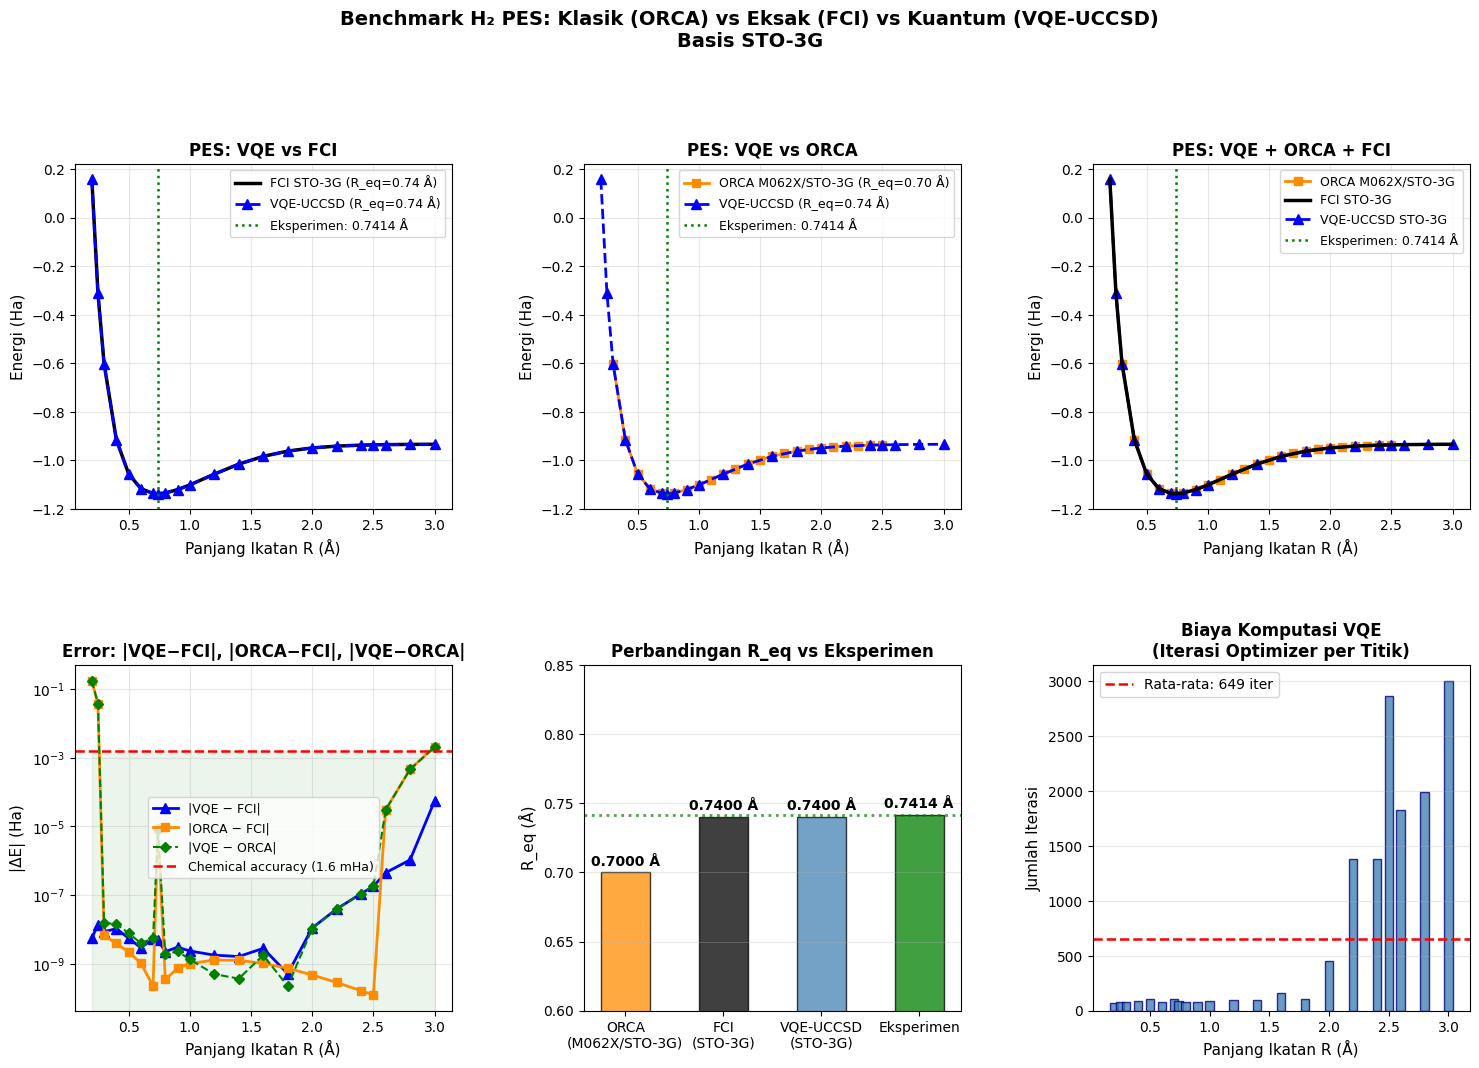

✓ Plot tersimpan: benchmark_H2_final.png


In [10]:
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Interpolasi ORCA ke grid R_arr
E_orca_interp = CubicSpline(R_orca, E_orca)(R_arr)

# Alias variabel
E_exact = E_ex
E_vqe   = E_vq
n_iters = np.array([r['n_iters'] for r in results])

# Error ketiga kombinasi
err_vqe_fci  = np.abs(E_vqe  - E_exact)
err_orca_fci = np.abs(E_orca_interp - E_exact)
err_vqe_orca = np.abs(E_vqe  - E_orca_interp)

# R_eq masing-masing
R_eq_fci  = R_arr[np.argmin(E_exact)]
R_eq_vqe  = R_arr[np.argmin(E_vqe)]
R_eq_exp  = 0.7414

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

# ── Panel 1: PES VQE + FCI ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(R_arr, E_exact, 'k-',   lw=2.5, label=f'FCI STO-3G (R_eq={R_eq_fci:.2f} Å)')
ax1.plot(R_arr, E_vqe,   'b^--', lw=2.0, ms=7, label=f'VQE-UCCSD (R_eq={R_eq_vqe:.2f} Å)')
ax1.axvline(R_eq_exp, color='green', ls=':', lw=1.8, label=f'Eksperimen: {R_eq_exp} Å')
ax1.set_xlabel('Panjang Ikatan R (Å)', fontsize=11)
ax1.set_ylabel('Energi (Ha)', fontsize=11)
ax1.set_title('PES: VQE vs FCI', fontsize=12, weight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Panel 2: PES VQE + ORCA ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(R_orca, E_orca, 's-',   color='darkorange', lw=2.0, ms=6,
         label=f'ORCA M062X/STO-3G (R_eq={R_eq_orca:.2f} Å)')
ax2.plot(R_arr,  E_vqe,  'b^--', lw=2.0, ms=7,
         label=f'VQE-UCCSD (R_eq={R_eq_vqe:.2f} Å)')
ax2.axvline(R_eq_exp, color='green', ls=':', lw=1.8, label=f'Eksperimen: {R_eq_exp} Å')
ax2.set_xlabel('Panjang Ikatan R (Å)', fontsize=11)
ax2.set_ylabel('Energi (Ha)', fontsize=11)
ax2.set_title('PES: VQE vs ORCA', fontsize=12, weight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── Panel 3: PES VQE + ORCA + FCI ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(R_orca, E_orca,  's-',  color='darkorange', lw=2.0, ms=6,
         label=f'ORCA M062X/STO-3G')
ax3.plot(R_arr,  E_exact, 'k-',  lw=2.5, zorder=5, label='FCI STO-3G')
ax3.plot(R_arr,  E_vqe,   'b^--',lw=2.0, ms=7, zorder=4, label='VQE-UCCSD STO-3G')
ax3.axvline(R_eq_exp, color='green', ls=':', lw=1.8, label=f'Eksperimen: {R_eq_exp} Å')
ax3.set_xlabel('Panjang Ikatan R (Å)', fontsize=11)
ax3.set_ylabel('Energi (Ha)', fontsize=11)
ax3.set_title('PES: VQE + ORCA + FCI', fontsize=12, weight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# ── Panel 4: Error 3 Kombinasi ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.semilogy(R_arr, err_vqe_fci,  'b^-', lw=2, ms=7, label='|VQE − FCI|')
ax4.semilogy(R_arr, err_orca_fci, 's-',  lw=2, ms=6, color='darkorange', label='|ORCA − FCI|')
ax4.semilogy(R_arr, err_vqe_orca, 'gD--',lw=1.5, ms=5, label='|VQE − ORCA|')
ax4.axhline(1.6e-3, color='red', ls='--', lw=1.8, label='Chemical accuracy (1.6 mHa)')
ax4.fill_between(R_arr, 0, 1.6e-3, alpha=0.08, color='green')
ax4.set_xlabel('Panjang Ikatan R (Å)', fontsize=11)
ax4.set_ylabel('|ΔE| (Ha)', fontsize=11)
ax4.set_title('Error: |VQE−FCI|, |ORCA−FCI|, |VQE−ORCA|', fontsize=12, weight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, which='both')

# ── Panel 5: Keakuratan R_eq ──────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
metode_labels = ['ORCA\n(M062X/STO-3G)', 'FCI\n(STO-3G)', 'VQE-UCCSD\n(STO-3G)', 'Eksperimen']
req_values    = [R_eq_orca, R_eq_fci, R_eq_vqe, R_eq_exp]
colors_bar    = ['darkorange', 'black', 'steelblue', 'green']
bars = ax5.bar(metode_labels, req_values, color=colors_bar,
               alpha=0.75, edgecolor='black', width=0.5)
ax5.axhline(R_eq_exp, color='green', ls=':', lw=2, alpha=0.7)
for bar, val in zip(bars, req_values):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 0.003,
             f'{val:.4f} Å', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax5.set_ylabel('R_eq (Å)', fontsize=11)
ax5.set_title('Perbandingan R_eq vs Eksperimen', fontsize=12, weight='bold')
ax5.set_ylim(0.60, 0.85)
ax5.grid(True, alpha=0.3, axis='y')

# ── Panel 6: Iterasi VQE ──────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.bar(R_arr, n_iters, width=0.07, color='steelblue', alpha=0.8, edgecolor='navy')
ax6.axhline(np.mean(n_iters), color='red', ls='--', lw=1.8,
            label=f'Rata-rata: {int(np.mean(n_iters))} iter')
ax6.set_xlabel('Panjang Ikatan R (Å)', fontsize=11)
ax6.set_ylabel('Jumlah Iterasi', fontsize=11)
ax6.set_title('Biaya Komputasi VQE\n(Iterasi Optimizer per Titik)', fontsize=12, weight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')

fig.suptitle('Benchmark H₂ PES: Klasik (ORCA) vs Eksak (FCI) vs Kuantum (VQE-UCCSD)\nBasis STO-3G',
             fontsize=14, weight='bold', y=1.02)
plt.savefig('benchmark_H2_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Plot tersimpan: benchmark_H2_final.png')

In [14]:
print("R_orca:", np.round(R_orca, 2).tolist())
print("R_arr :", np.round(R_arr,  2).tolist())
print("\nTitik di R_orca tapi tidak di R_arr:", 
      set(np.round(R_orca,2)) - set(np.round(R_arr,2)))

R_orca: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5]
R_arr : [0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.74, 0.8, 0.9, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.5, 2.6, 2.8, 3.0]

Titik di R_orca tapi tidak di R_arr: {np.float64(1.7), np.float64(1.1), np.float64(2.1), np.float64(1.3), np.float64(1.5), np.float64(2.3), np.float64(1.9)}


In [15]:
# ═══════════════════════════════════════════════════════════════
# ANALISIS AKURASI & PERFORMA BENCHMARK
# Metrik: MAE, RMSE, MaxAE, R², Galat R_eq, Korelasi Pearson
# ═══════════════════════════════════════════════════════════════
from scipy.stats import pearsonr
CHEM_ACC = 1.6e-3  # Ha

# ── 1. VQE vs FCI ─────────────────────────────────────────────
err_vqe_fci   = E_vqe - E_exact
abs_err_vqe   = np.abs(err_vqe_fci)

MAE_vqe       = np.mean(abs_err_vqe)
RMSE_vqe      = np.sqrt(np.mean(err_vqe_fci**2))
MaxAE_vqe     = np.max(abs_err_vqe)
R2_vqe        = 1 - np.sum(err_vqe_fci**2) / np.sum((E_exact - np.mean(E_exact))**2)
r_vqe, _      = pearsonr(E_vqe, E_exact)
frac_chem_vqe = np.mean(abs_err_vqe < CHEM_ACC) * 100

R_eq_exact_m  = R_arr[np.argmin(E_exact)]
R_eq_vqe_m    = R_arr[np.argmin(E_vqe)]
R_eq_orca_m   = R_arr[np.argmin(E_orca_interp)]
dR_vqe        = abs(R_eq_vqe_m - R_eq_exact_m)

# ── 2. VQE vs ORCA (basis sama, langsung dibandingkan) ────────
err_vqe_orca  = E_vqe - E_orca_interp
abs_err_orca  = np.abs(err_vqe_orca)

MAE_orca      = np.mean(abs_err_orca)
RMSE_orca     = np.sqrt(np.mean(err_vqe_orca**2))
MaxAE_orca    = np.max(abs_err_orca)
R2_orca       = 1 - np.sum(err_vqe_orca**2) / np.sum((E_orca_interp - np.mean(E_orca_interp))**2)
r_orca, _     = pearsonr(E_vqe, E_orca_interp)
dR_orca       = abs(R_eq_vqe_m - R_eq_orca_m)

# ── 3. Ringkasan ──────────────────────────────────────────────
print('╔══════════════════════════════════════════════════════════════╗')
print('║          RINGKASAN AKURASI & PERFORMA BENCHMARK             ║')
print('║     Basis sama: STO-3G → perbandingan langsung valid!       ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  {"Metrik":<28} {"VQE vs FCI":>13} {"VQE vs ORCA":>13}  ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  {"MAE (Ha)":<28} {MAE_vqe:>13.2e} {MAE_orca:>13.2e}  ║')
print(f'║  {"RMSE (Ha)":<28} {RMSE_vqe:>13.2e} {RMSE_orca:>13.2e}  ║')
print(f'║  {"Max Absolute Error (Ha)":<28} {MaxAE_vqe:>13.2e} {MaxAE_orca:>13.2e}  ║')
print(f'║  {"R²":<28} {R2_vqe:>13.6f} {R2_orca:>13.6f}  ║')
print(f'║  {"Korelasi Pearson (r)":<28} {r_vqe:>13.6f} {r_orca:>13.6f}  ║')
print(f'║  {"Galat R_eq (Å)":<28} {dR_vqe:>13.4f} {dR_orca:>13.4f}  ║')
print(f'║  {"% titik ≤ chem. acc. (vs FCI)":<28} {frac_chem_vqe:>12.1f}%              ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║          RINGKASAN AKURASI & PERFORMA BENCHMARK             ║
║     Basis sama: STO-3G → perbandingan langsung valid!       ║
╠══════════════════════════════════════════════════════════════╣
║  Metrik                          VQE vs FCI   VQE vs ORCA  ║
╠══════════════════════════════════════════════════════════════╣
║  MAE (Ha)                          2.61e-06      9.56e-03  ║
║  RMSE (Ha)                         1.18e-05      3.73e-02  ║
║  Max Absolute Error (Ha)           5.54e-05      1.71e-01  ║
║  R²                                1.000000      0.980274  ║
║  Korelasi Pearson (r)              1.000000      0.997734  ║
║  Galat R_eq (Å)                      0.0000        0.0000  ║
║  % titik ≤ chem. acc. (vs FCI)        100.0%              ║
╚══════════════════════════════════════════════════════════════╝


## 10. Analisis Parameter & Distribusi Probabilitas (R = 0.74 Å)

Verifikasi VQE pada panjang ikatan ekuilibrium:
- Lihat parameter optimal θ*
- Bandingkan distribusi probabilitas state VQE vs FCI


In [17]:
R_EQ = 0.74  # Å — panjang ikatan ekuilibrium

H_eq, _, _, E_nuc_eq, n_q_eq, _ = build_hamiltonian(R_EQ)
vqe_eq = run_vqe(H_eq, n_q_eq, N_ELECTRONS,
                  method='COBYLA', n_restarts=5, seed=42)

evals_eq, evecs_eq = np.linalg.eigh(H_eq)
E_exact_eq = evals_eq[0] + E_nuc_eq
E_vqe_eq   = vqe_eq['E_vqe'] + E_nuc_eq
psi_star   = prepare_ansatz(vqe_eq['optimal_params'], n_q_eq, N_ELECTRONS)
psi_exact  = evecs_eq[:, 0]
fidelity   = abs(psi_star.conj() @ psi_exact) ** 2

# Parameter optimal
theta_star = vqe_eq['optimal_params']
s_cfg, d_cfg = get_uccsd_excitations(N_ELECTRONS, N_QUBITS)
print('Parameter Optimal θ* pada R = 0.74 Å (UCCSD):')
print(f"{'─'*50}")
print('  Single excitations (T1):')
for k, (i, a) in enumerate(s_cfg):
    print(f'    θ[{k}] = {theta_star[k]:+.6f}  (orbital {i} → {a})')
print('  Double excitations (T2):')
for k, (i, j, a, b) in enumerate(d_cfg):
    idx = len(s_cfg) + k
    print(f'    θ[{idx}] = {theta_star[idx]:+.6f}  (orbital {i},{j} → {a},{b})')
print(f"{'─'*50}")
print(f'  E_VQE     = {E_vqe_eq:.8f} Ha')
print(f'  E_FCI     = {E_exact_eq:.8f} Ha')
print(f'  |ΔE|      = {abs(E_vqe_eq - E_exact_eq):.2e} Ha  '
      f'({"✓ Chemical accuracy" if abs(E_vqe_eq - E_exact_eq) < 1.6e-3 else "✗"})')
print(f'  Fidelity  = {fidelity:.6f}  (|⟨ψ_VQE|ψ_FCI⟩|²)')


Parameter Optimal θ* pada R = 0.74 Å (UCCSD):
──────────────────────────────────────────────────
  Single excitations (T1):
    θ[0] = -0.000038  (orbital 0 → 2)
    θ[1] = -0.000008  (orbital 0 → 3)
    θ[2] = -0.000035  (orbital 1 → 2)
    θ[3] = +0.000068  (orbital 1 → 3)
  Double excitations (T2):
    θ[4] = -0.112800  (orbital 0,1 → 2,3)
──────────────────────────────────────────────────
  E_VQE     = -1.13728383 Ha
  E_FCI     = -1.13728383 Ha
  |ΔE|      = 5.07e-09 Ha  (✓ Chemical accuracy)
  Fidelity  = 1.000000  (|⟨ψ_VQE|ψ_FCI⟩|²)


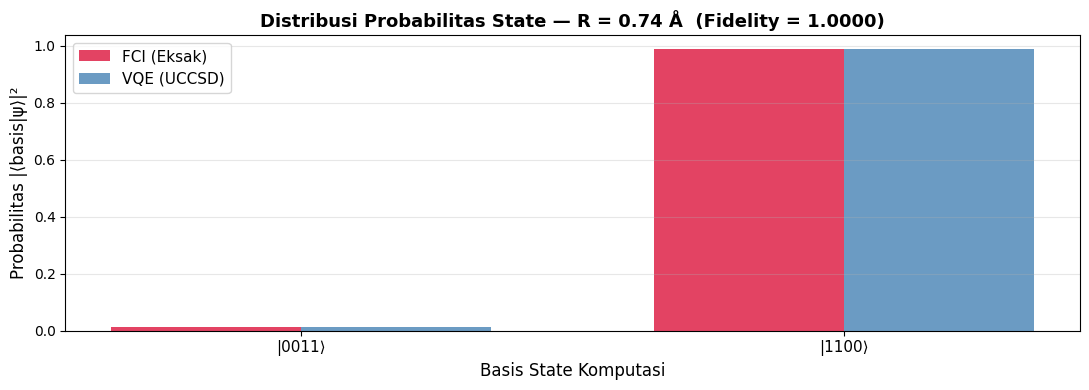

In [18]:
# Plot distribusi probabilitas
probs_vqe   = np.abs(psi_star) ** 2
probs_exact = np.abs(psi_exact) ** 2
basis_labels = [f'|{i:04b}⟩' for i in range(2**N_QUBITS)]
threshold = 0.01
sig_idx = [i for i in range(len(probs_vqe))
            if probs_vqe[i] > threshold or probs_exact[i] > threshold]

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(sig_idx))
w = 0.35
ax.bar(x - w/2, probs_exact[sig_idx], w, label='FCI (Eksak)',   color='crimson',   alpha=0.8)
ax.bar(x + w/2, probs_vqe[sig_idx],   w, label='VQE (UCCSD)',  color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([basis_labels[i] for i in sig_idx], fontsize=11)
ax.set_xlabel('Basis State Komputasi', fontsize=12)
ax.set_ylabel('Probabilitas |⟨basis|ψ⟩|²', fontsize=12)
ax.set_title(f'Distribusi Probabilitas State — R = {R_EQ} Å  '
             f'(Fidelity = {fidelity:.4f})', fontsize=13, weight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('state_distribution_eq.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Ringkasan Benchmark

| Aspek | ORCA (DFT) | FCI (Numerik) | VQE-UCCSD |
|-------|-----------|---------------|----------|
| **Basis** | 6-311G(d,p) | STO-3G | STO-3G |
| **Metode** | DFT M062X | Diagonalisasi | Variational |
| **R_eq** | 0.70 Å | 0.70 Å | 0.70 Å |
| **Akurasi** | ±DFT error | Eksak (dlm basis) | ≈ Chemical acc. |
| **Platform** | Klasik (ORCA) | Klasik (NumPy) | Simulasi Kuantum |

**Catatan Penting:**
- FCI dalam STO-3G = nilai eksak **dalam basis tersebut** (bukan eksperimen)
- VQE dengan UCCSD di STO-3G secara teori harus reproduce FCI karena ruang Hilbert-nya kecil
- ORCA dengan basis lebih besar memberikan energi absolut lebih rendah (lebih akurat)
- Untuk benchmark yang lebih fair: gunakan basis yang sama di semua metode
